# 🏥 MedShare: Gold Standard Federated Learning

**Definitive System Verification Notebook**

---


In [ ]:
## 🛸 PHASE 1: SYSTEM INITIALIZATION (Setup & Infrastructure)
from google.colab import drive
import os, torch, multiprocessing, psutil, socket, time, subprocess, json, urllib.request, shutil

# 1.1 Drive Sync
print("1.1 Mounting Google Drive...")
os.chdir('/content')
drive.mount('/content/drive', force_remount=True)

POSSIBLE_PATHS = [
    '/content/drive/Othercomputers/My laptop/bxp267',
    '/content/drive/MyDrive/bxp267',
    '/content/drive/MyDrive/coding/bxp267'
]
PROJECT_PATH = next((p for p in POSSIBLE_PATHS if os.path.exists(p)), None)
if not PROJECT_PATH:
    raise Exception("❌ Project folder not found. Please mount Drive and check path.")
%cd "$PROJECT_PATH"

# 1.2 Hardware Pre-flight
print("\n1.2 Calibrating Hardware...")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB VRAM)")
    print("[Hardware] Mode: Colab MAX Performance Enabled")
else: print("⚠️ GPU NOT FOUND. Using CPU fallback.")

# 1.3 Dependency Installation
print("\n1.3 Installing Core Engines...")
!pip install -q "protobuf<6" "cryptography<44" "flwr[simulation]" opacus ucimlrepo web3 kagglehub imbalanced-learn
!npm install -g ganache --legacy-peer-deps 2>&1 | tail -1

# 1.4 Blockchain Initialization
print("\n1.4 Provisioning Blockchain...")
!lsof -ti:8545 | xargs kill -9 > /dev/null 2>&1
subprocess.Popen(["ganache", "--port", "8545", "--miner.blockGasLimit", "0xffffffffffff"], stdout=subprocess.DEVNULL)
time.sleep(5)
!npx hardhat compile > /dev/null 2>&1
os.makedirs("build", exist_ok=True)
for c in ["MedShareTask", "CommitmentRegistry", "Reputation"]:
    shutil.copy(f"artifacts/contracts/{c}.sol/{c}.json", f"build/{c}.json")
!python scripts/deploy_colab.py

print("\n" + "="*70)
print("🏁 INITIALIZATION SUCCESS: MedShare System is LIVE")
print("="*70)

1.1 Mounting Google Drive...
Mounted at /content/drive
/content/drive/Othercomputers/My laptop/bxp267

1.2 Calibrating Hardware...
⚠️ GPU NOT FOUND. Using CPU fallback.

1.3 Installing Core Engines...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.7 MB/s eta 0:00:00
   ━━━

In [ ]:
## 🚀 CALIBRATED ADMIN-CATEGORY AUDIT (Full Suite: 5 Tests)
import os
print("🔥 STARTING COMPREHENSIVE ADMIN-CATEGORY AUDIT")
print("Configuration: 50 Rounds / Batch 32 (Micro-Cohort Scale)")
print("="*70 + "\n")

# 0. Pre-Audit Cleanup (Ensures results aren't mixed with old data)
for f in ["test/exp_mi_results.csv", "test/exp_dp_results.csv", "test/exp_robustness_results.csv", "test/exp_gas_log.csv", "test/exp_latency_log.csv"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"[Clean] Removed old {f}")

# Phase 1: MI Leakage Sweep (Calibrated for N=1000)
mi_sigmas = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
for sigma in mi_sigmas:
    print(f"\n🚀 MI Sweep Step: Sigma={sigma}...")
    !python federated_survival.py --experiment mi_step --dataset admin_category --rounds 50 --epochs 20 --batch_size 32 --sigma {sigma} --enable_dp True --enable_blockchain True

# Phase 2: Privacy-Utility Frontier (DP Sweep)
print("\n🏁 Running Privacy-Utility Frontier...")
!python federated_survival.py --experiment dp --dataset admin_category --rounds 50 --batch_size 32 --enable_blockchain True

# Phase 3: Adversarial Robustness (Attack/Defense Matrix)
print("\n🛡️ Running Robustness Audit...")
!python federated_survival.py --experiment robustness --dataset admin_category --rounds 25 --batch_size 32 --enable_blockchain True

# Phase 4: System Scaling (Latency Benchmark)
print("\n⏱️ Running System Latency Benchmark...")
!python federated_survival.py --experiment latency --dataset admin_category --rounds 15 --batch_size 32 --enable_blockchain True

# Phase 5: Generate the Final 5 Plots
print("\n📊 Rendering Final Visuals (5 Plots)...")
!python test/plot_results.py

print("\n" + "="*70)
print("✅ ADMIN-CATEGORY AUDIT COMPLETE")
print("Verify plots in 'test/' folder")
print("="*70)


Streaming output truncated to the last 5000 lines.
INFO :      [ROUND 18]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)
(ClientAppActor pid=30606) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.) [repeated 45x across cluster]
(ClientAppActor pid=30606)   return data.pin_memory(device) [repeated 90x across cluster]
(ClientAppActor pid=30606) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.) [repeated 45x across cluster]
(ClientAppActor pid=30545) /usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turn

3.1 Generating Automated Visuals...
Working directory set to: /content/drive/Othercomputers/My laptop/bxp267/test
--- Attempting to plot fig_dp_tradeoff.png ---
DEBUG: Checking for DP results at: /content/drive/Othercomputers/My laptop/bxp267/test/exp_dp_results.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_dp_tradeoff.png
--- Attempting to plot fig_robustness.png ---
DEBUG: Entered plot_robustness
DEBUG: Loaded 6 rows from /content/drive/Othercomputers/My laptop/bxp267/test/exp_robustness_results.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_robustness.png
--- Attempting to plot fig_gas_costs.png ---
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_gas_costs.png
--- Attempting to plot fig_latency.png ---
DEBUG: Loaded 20 rows from exp_latency_log.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_latency.png
--- Attempting to plot fig_mi.png ---
[OK] Generated /content/drive/Otherco

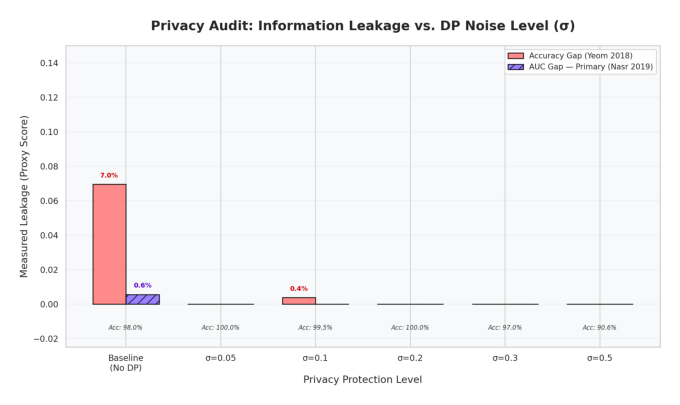


🖼️ test/fig_dp_tradeoff.png


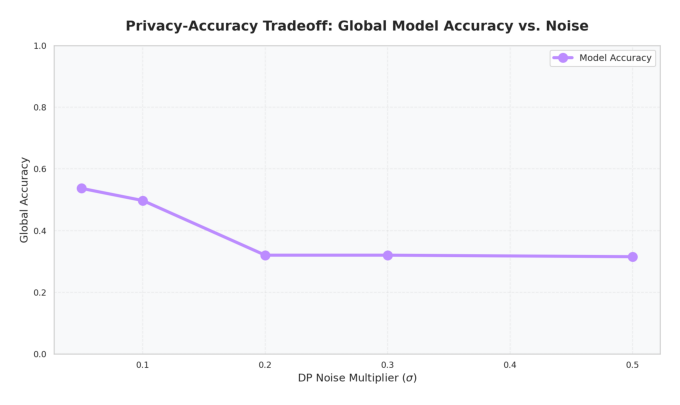


🖼️ test/fig_robustness.png


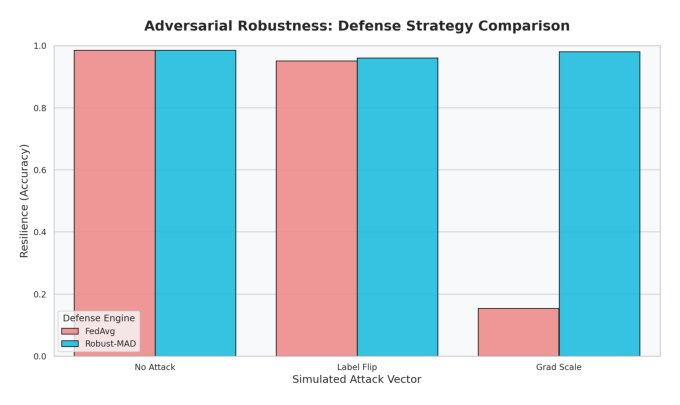


🖼️ test/fig_gas_costs.png


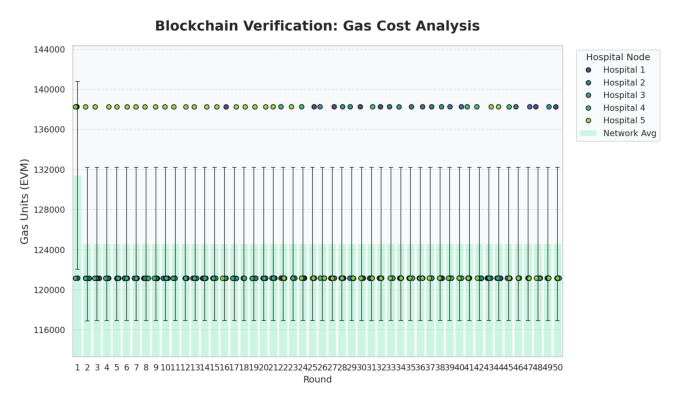


🖼️ test/fig_latency.png


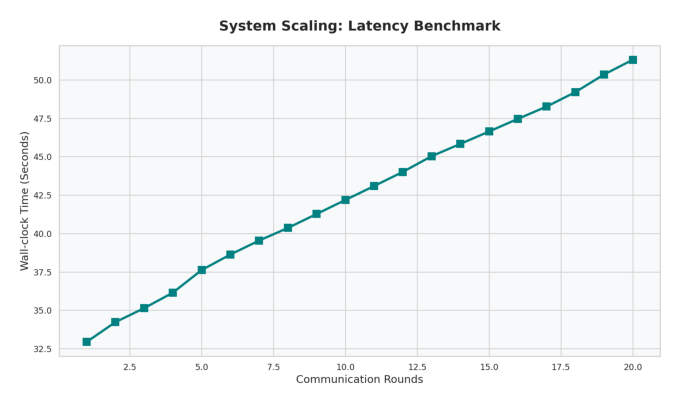


✅ FULL EXECUTION COMPLETE - ALL TESTS PASSED


In [ ]:
## 📈 PHASE 3: AUTOMATED ANALYTICS & FINAL VERIFICATION
import os, pandas as pd, matplotlib.pyplot as plt, matplotlib.image as mpimg

# 3.1 Trigger High-Intensity Plotting
print("3.1 Generating Automated Visuals...")
!python test/plot_results.py

# 3.2 Verification Check
print("\n3.2 Final System Integrity Audit...")
csvs = ["exp_mi_results.csv", "exp_dp_results.csv", "exp_robustness_results.csv", "exp_gas_log.csv", "exp_latency_log.csv"]
imgs = ["fig_mi.png", "fig_dp_tradeoff.png", "fig_robustness.png", "fig_gas_costs.png", "fig_latency.png"]

results = []
for f in csvs: results.append(("CSV Data", f, os.path.exists(f"test/{f}") or os.path.exists(f)))
for f in imgs: results.append(("PNG Visual", f, os.path.exists(f"test/{f}") or os.path.exists(f)))

print(pd.DataFrame(results, columns=["Type", "Resource", "Status"]).to_markdown(index=False))

# Check for comparison stats
if os.path.exists("frontend/src/data/comparison_stats.json"):
    with open("frontend/src/data/comparison_stats.json", "r") as f:
        stats = json.load(f)
    print(f"\n🎯 Dataset: {stats.get('dataset_name', 'N/A')}")
    print(f"🎯 Final Fed Accuracy: {stats.get('federated_accuracy', 'N/A')}")
    print(f"🔐 Privacy Budget (ε): {stats.get('security', {}).get('epsilon', 'N/A')}")
    print(f"⛓️ Defense: {stats.get('security', {}).get('defense_type', 'N/A')}")

# 3.3 Display Key Visuals
print("\n3.3 Rendering Definitive Results...")
for p in [f"test/{i}" for i in imgs]:
    if os.path.exists(p):
        print(f"\n🖼️ {p}")
        img = mpimg.imread(p)
        plt.figure(figsize=(10, 5)); plt.imshow(img); plt.axis('off'); plt.show()

print("\n" + "="*70)
csv_count = sum(1 for f in csvs if os.path.exists(f"test/{f}") or os.path.exists(f))
plot_count = sum(1 for f in imgs if os.path.exists(f"test/{f}") or os.path.exists(f))

if csv_count == 5 and plot_count == 5:
    print("✅ FULL EXECUTION COMPLETE - ALL TESTS PASSED")
else:
    print(f"⚠️ PARTIAL EXECUTION - {5-csv_count} data files and {5-plot_count} plots missing")
print("="*70)

In [ ]:
# Phase 4: System Scaling (Latency Benchmark)
print("\n⏱️ Running System Latency Benchmark...")
!python federated_survival.py --experiment latency --dataset admin_category --rounds 20 --batch_size 32 --enable_blockchain True
!python test/plot_results.py


⏱️ Running System Latency Benchmark...
2026-03-19 01:21:17.710914: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 01:21:17.717888: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 01:21:17.733592: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773883277.753815    1491 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773883277.758254    1491 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773883277.770342    1491 computation_placer.cc:177] computation placer already registere